In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
def shulie(shuzi,suoyin):
    mylist=list(range(-1*(shuzi//2), 1*(shuzi//2)+1))
    if mylist[suoyin]>0 and mylist[suoyin]%2==1:
        return -1,1
    if mylist[suoyin]>0 and mylist[suoyin]%2==0:
        return  1,0
    if mylist[suoyin] ==0 :
        return  0,0
    if mylist[suoyin]<0 and mylist[suoyin]%2==1:
        return  1,1
    if mylist[suoyin]<0 and mylist[suoyin]%2==0:
        return  -1,0
def matric_zhongjian(const, e, t, a, ky, shuzi,zazhi):
    full_matrix = np.zeros((2*shuzi, 2*shuzi), dtype=complex)
    for i in range(shuzi):
        diyishu, diershu = shulie(shuzi, i)
        #print(diyishu, diershu)
        matric = np.array([[-diyishu*const/2 + e, t*np.exp(3j*a*ky*diershu)],
                          [t*np.exp(-3j*a*ky*diershu), 1*diyishu*const/2 + e]])
        start_idx = 2 * i
        full_matrix[start_idx:start_idx+2, start_idx:start_idx+2] = matric
    feiduijiao = np.array([[t, 0], [0, t]])
    for i in range(shuzi - 1):
        # 上对角非对角块
        start_row = 2 * i
        start_col = 2 * (i + 1)
        full_matrix[start_row:start_row+2, start_col:start_col+2] = feiduijiao 
        # 下对角非对角块
        full_matrix[start_col:start_col+2, start_row:start_row+2] = feiduijiao
    return full_matrix+np.diag(np.random.uniform(zazhi[0], zazhi[1], shuzi*2))
def calculate_band_structure(const, e, t, a, shuzi, ky_points,zazhi):
    ky_set = np.linspace(-np.pi*1/(3*a), np.pi*1/(3*a), ky_points)
    if 0 not in ky_set:
        ky_set = np.sort(np.append(ky_set, 0))
    matrix_size = 2 * shuzi  # 矩阵的总大小
    eigenvalues_all = [[] for _ in range(matrix_size)]  # 为每个能带创建空列表
    
    for ky in ky_set:
        H_matrix = matric_zhongjian(const, e, t, a, ky, shuzi,zazhi)
        eigenvalues = np.linalg.eigvals(H_matrix)
        eigenvalues_sorted = sorted(eigenvalues, key=lambda x: x.real)  

        for band_idx in range(matrix_size):
            eigenvalues_all[band_idx].append(eigenvalues_sorted[band_idx].real)
    
    return ky_set, eigenvalues_all
    

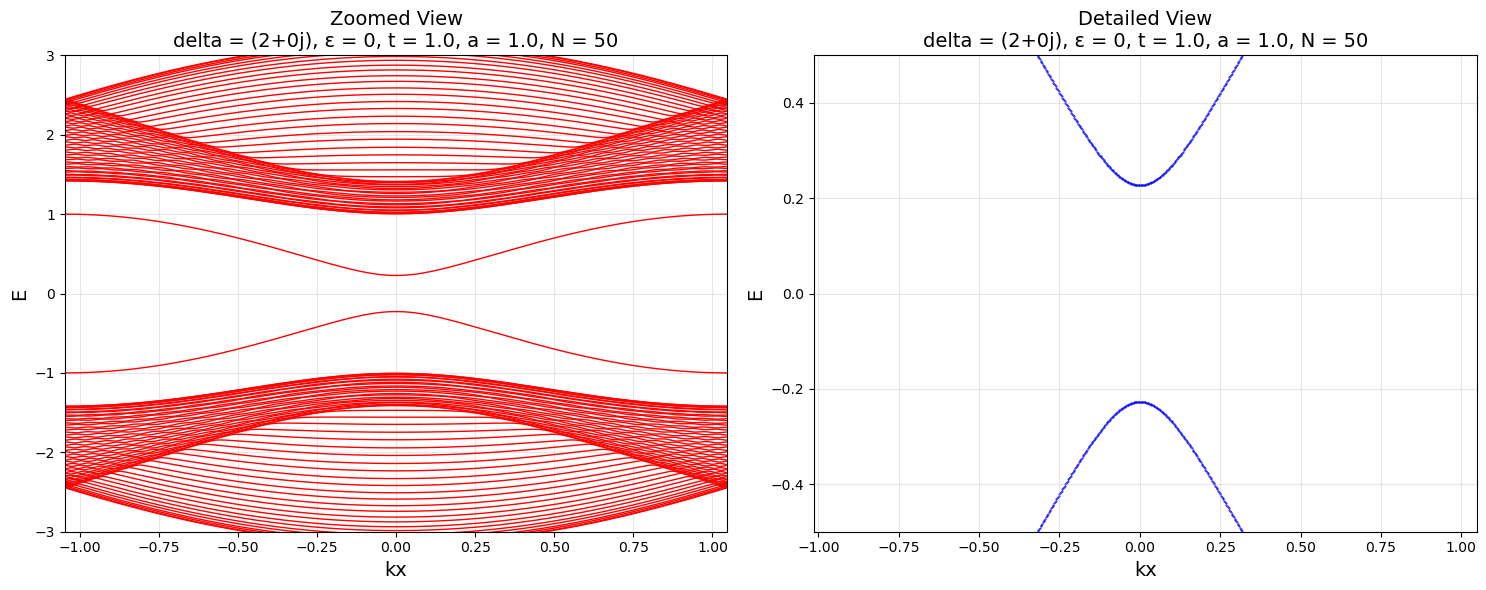

In [60]:
def plot_band_structure_dual(ky_set, eigenvalues_all, delta1, delta, epsilon, t, a, N):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # ------- 左图：曲线 plot -------
    for band_idx, band_energies in enumerate(eigenvalues_all):
        ax1.plot(ky_set, band_energies, color='red', linewidth=1)
    
    # ------- 右图：散点 scatter -------
    for band_idx, band_energies in enumerate(eigenvalues_all):
        ax2.scatter(ky_set, band_energies, color='blue', s=0.2)  # ←← 在这里改散点大小

    # ------- 左图设置 -------
    ax1.set_xlabel('kx', fontsize=14)
    ax1.set_ylabel('E', fontsize=14)
    param_str = f"delta = {delta}, ε = {epsilon}, t = {t}, a = {a}, N = {N}"
    ax1.set_title(f'Zoomed View\n{param_str}', fontsize=14)  # ← 保留你的标题
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-np.pi/3., np.pi/3)
    ax1.set_ylim(-3, 3)
    
    # ------- 右图设置 -------
    ax2.set_xlabel('kx', fontsize=14)
    ax2.set_ylabel('E', fontsize=14)
    ax2.set_title(f'Detailed View\n{param_str}', fontsize=14)  # ← 保留你的标题
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-np.pi/3.1, np.pi/3)

    if delta1 == 0:
        ax2.set_ylim(-0.03, 0.03)
    else:
        ax2.set_ylim(-0.5, 0.5)

    plt.tight_layout()
    plt.show()
# 参数设置
delta1 = 2
delta2 = 0
delta = delta1 + 1j*delta2
epsilon = 0
t = 1.0
a = 1.0
N = 50
ky_points = 900
zazhi = [0, 0]

# 计算并画能带
ky_set, eigenvalues_all = calculate_band_structure(delta, epsilon, t, a, N, ky_points, zazhi)
plot_band_structure_dual(ky_set, eigenvalues_all, delta1, delta, epsilon, t, a, N)

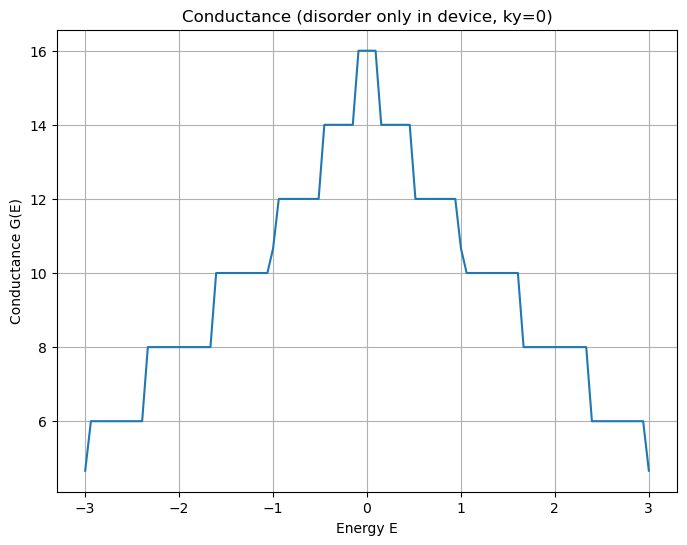

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ================== 辅助函数 =================
def shulie(shuzi,suoyin):
    mylist=list(range(-1*(shuzi//2), 1*(shuzi//2)+1))
    if mylist[suoyin]>0 and mylist[suoyin]%2==1:
        return -1,1
    if mylist[suoyin]>0 and mylist[suoyin]%2==0:
        return  1,0
    if mylist[suoyin] ==0 :
        return  0,0
    if mylist[suoyin]<0 and mylist[suoyin]%2==1:
        return  1,1
    if mylist[suoyin]<0 and mylist[suoyin]%2==0:
        return  -1,0

# ============= 构造完整哈密顿量 ==============
def H_full(const, e, t, a, ky, shuzi, zazhi):
    H = np.zeros((2*shuzi, 2*shuzi), dtype=complex)

    for i in range(shuzi):
        diyishu, diershu = shulie(shuzi, i)
        block = np.array([
            [-diyishu*const/2 + e, t*np.exp(3j*a*ky*diershu)],
            [t*np.exp(-3j*a*ky*diershu), +diyishu*const/2 + e]
        ])
        H[2*i:2*i+2, 2*i:2*i+2] = block

    feiduijiao = np.array([[t,0],[0,t]])
    for i in range(shuzi-1):
        H[2*i:2*i+2, 2*(i+1):2*(i+1)+2] = feiduijiao
        H[2*(i+1):2*(i+1)+2, 2*i:2*i+2] = feiduijiao

    # 可控无序
    if zazhi is not None:
        H += np.diag(np.random.uniform(zazhi[0], zazhi[1], 2*shuzi))
    return H

# ============= 提取跃迁矩阵 T ==============
def extract_T(t, a, ky, shuzi):
    T = np.zeros((2*shuzi, 2*shuzi), dtype=complex)

    for i in range(shuzi):
        _, diershu = shulie(shuzi, i)
        phase = np.exp(3j*a*ky*diershu)

        r = 2*i
        c = 2*i + 1
        T[r, c] = t * phase
        T[c, r] = t * np.conj(phase)

    return T

# =============== 表面格林函数 ==============
def gsr_func(ALR0, T):
    gs = np.linalg.inv(ALR0)
    for _ in range(1000):
        zg = T.conj().T @ gs @ T
        gs_new = np.linalg.inv(ALR0 - zg)
        gs = 0.5*gs + 0.5*gs_new
    return gs

# ================= 计算电导 =================
def calc_conductance(E_list, V):
    G_list = []
    dim = 2 * shuzi

    # 器件区（有无序）
    H_device = H_full(const, e, t, a, ky, shuzi, zazhi)
    Tmat = extract_T(t, a, ky, shuzi)
    H0_device = H_device - Tmat

    # 引线（无无序）
    H_lead = H_full(const, e, t, a, ky, shuzi, (0,0))
    H0_lead = H_lead - Tmat

    for E in E_list:
        z = E + 1j*eta

        # 引线表面格林函数
        ALR0_lead = z*np.eye(dim) - H0_lead
        gL = gsr_func(ALR0_lead, Tmat)
        gR = gsr_func(ALR0_lead, Tmat)

        # 自能
        SigmaL = Tmat.conj().T @ gL @ Tmat
        SigmaR = Tmat @ gR @ Tmat.conj().T

        # Γ
        GammaL = 1j * (SigmaL - SigmaL.conj().T)
        GammaR = 1j * (SigmaR - SigmaR.conj().T)

        # 器件格林函数（只在这里加 V + 无序）
        ALR_device = z*np.eye(dim) - (H0_device + V*np.eye(dim))
        GR = np.linalg.inv(ALR_device - SigmaL - SigmaR)

        # 透射
        TE = np.real(np.trace(GammaL @ GR @ GammaR @ GR.conj().T))
        G_list.append(TE)

    return np.array(G_list)

# ================== 参数 & 运行 ==================
delta1 = 0
delta2 = 0
const = delta1 + 1j*delta2
e = 0.0
t = 1.0
a = 1.0
ky = 0
shuzi = 8
zazhi = (0, 0)         # 只在器件区生效，设为 (0,0) 即无无序
eta = 1e-5
V = 0

E_values = np.linspace(-3, 3, 100)
G_values = calc_conductance(E_values, V)

# ================== 绘图 ==================
plt.figure(figsize=(8,6))
plt.plot(E_values, G_values)
plt.xlabel("Energy E")
plt.ylabel("Conductance G(E)")
plt.title("Conductance (disorder only in device, ky=0)")
plt.grid(True)
plt.show()


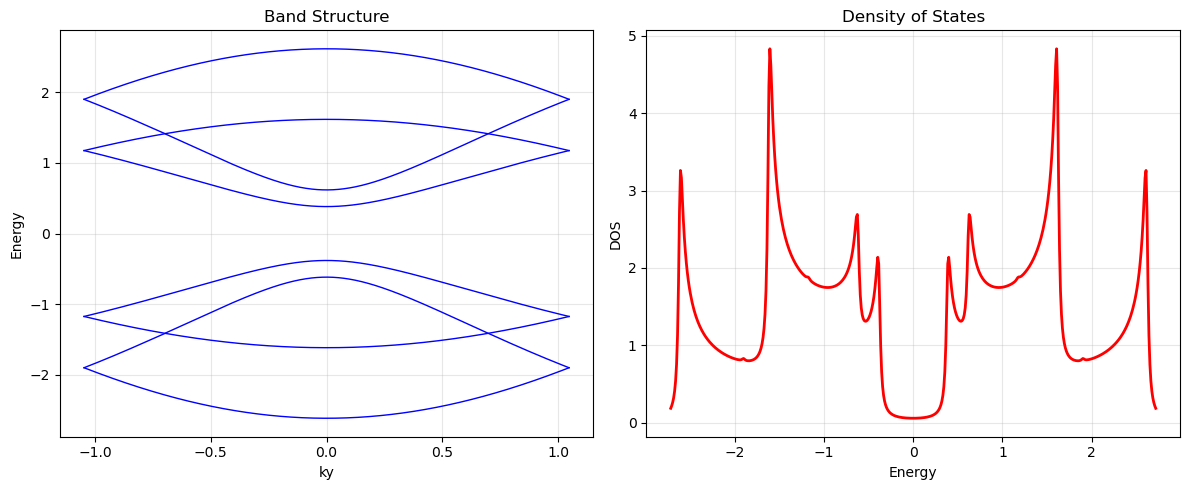

能量范围: -2.718 到 2.718
DOS 最大值: 4.831
DOS 最小值: 0.057


In [50]:
import numpy as np
import matplotlib.pyplot as plt

# ================= 参数设置 =================
a = 1.0
t = 1.0
const = 0
e = 0.0
shuzi = 4
zazhi = (0, 0)

ky_points = 1000
eta = 0.02

# ================= 你的函数 =================
def shulie(shuzi,suoyin):
    mylist=list(range(-1*(shuzi//2), 1*(shuzi//2)+1))
    if mylist[suoyin]>0 and mylist[suoyin]%2==1:
        return -1,1
    if mylist[suoyin]>0 and mylist[suoyin]%2==0:
        return  1,0
    if mylist[suoyin] ==0 :
        return  0,0
    if mylist[suoyin]<0 and mylist[suoyin]%2==1:
        return  1,1
    if mylist[suoyin]<0 and mylist[suoyin]%2==0:
        return  -1,0

def matric_zhongjian(const, e, t, a, ky, shuzi,zazhi):
    full_matrix = np.zeros((2*shuzi, 2*shuzi), dtype=complex)
    for i in range(shuzi):
        diyishu, diershu = shulie(shuzi, i)
        matric = np.array([
            [-diyishu*const/2 + e, t*np.exp(3j*a*ky*diershu)],
            [t*np.exp(-3j*a*ky*diershu), +diyishu*const/2 + e]
        ])
        idx = 2*i
        full_matrix[idx:idx+2, idx:idx+2] = matric

    feiduijiao = np.array([[t,0],[0,t]])
    for i in range(shuzi - 1):
        r = 2*i
        c = 2*(i+1)
        full_matrix[r:r+2, c:c+2] = feiduijiao
        full_matrix[c:c+2, r:r+2] = feiduijiao

    return full_matrix + np.diag(np.random.uniform(zazhi[0], zazhi[1], 2*shuzi))

# ============== 扫描 ky，算能带 =================
ky_set = np.linspace(-np.pi/(3*a), np.pi/(3*a), ky_points)

dim = 2 * shuzi
bands = np.zeros((ky_points, dim))

for i, ky in enumerate(ky_set):
    H = matric_zhongjian(const, e, t, a, ky, shuzi, zazhi)
    ev = np.linalg.eigvals(H)
    bands[i,:] = np.sort(ev.real)

# ============== 计算 DOS =================
E_min = np.min(bands) -0.1
E_max = np.max(bands) +0.1
E_values = np.linspace(E_min, E_max, 500)

def calc_DOS(E_values, bands, eta):
    dos = np.zeros_like(E_values)
    Nk, Nb = bands.shape
    for i, E in enumerate(E_values):
        s = 0.0
        for k in range(Nk):
            for n in range(Nb):
                en = bands[k,n]
                s += eta / np.pi / ((E - en)**2 + eta**2)
        dos[i] = s / Nk
    return dos

dos = calc_DOS(E_values, bands, eta)

# ============== 作图 =================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for n in range(dim):
    plt.plot(ky_set, bands[:,n], 'b', lw=1)
plt.xlabel("ky")
plt.ylabel("Energy")
plt.title("Band Structure")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(E_values, dos, 'r', lw=2)
plt.xlabel("Energy")
plt.ylabel("DOS")
plt.title("Density of States")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============== 输出信息 =================
print(f"能量范围: {E_min:.3f} 到 {E_max:.3f}")
print(f"DOS 最大值: {np.max(dos):.3f}")
print(f"DOS 最小值: {np.min(dos):.3f}")


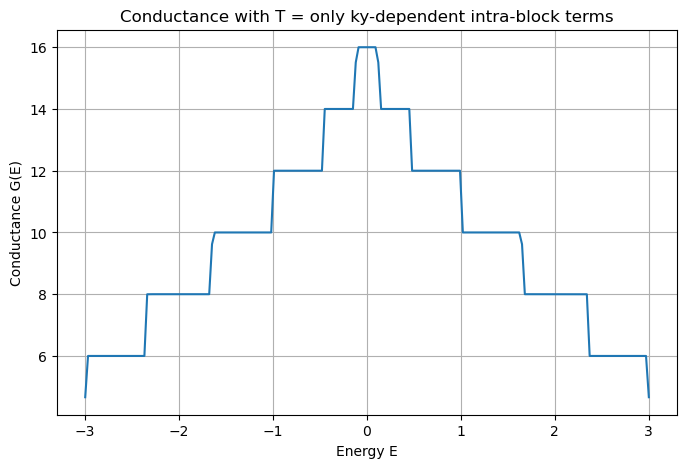

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ================== 辅助函数 =================
def shulie(shuzi, suoyin):
    mylist = list(range(-1*(shuzi//2), 1*(shuzi//2)+1))
    if mylist[suoyin] > 0 and mylist[suoyin] % 2 == 1:
        return -1, 1
    if mylist[suoyin] > 0 and mylist[suoyin] % 2 == 0:
        return 1, 0
    if mylist[suoyin] == 0:
        return 0, 0
    if mylist[suoyin] < 0 and mylist[suoyin] % 2 == 1:
        return 1, 1
    if mylist[suoyin] < 0 and mylist[suoyin] % 2 == 0:
        return -1, 0

# ============= 构造完整哈密顿量 H ==============
def H_full(const, e, t, a, ky, shuzi, zazhi):
    H = np.zeros((2*shuzi, 2*shuzi), dtype=complex)

    # 每个 2x2 block（包含 ky 相位 的 A-B 元素）
    for i in range(shuzi):
        diyishu, diershu = shulie(shuzi, i)
        block = np.array([
            [-diyishu*const/2 + e, t*np.exp(3j*a*ky*diershu)],
            [t*np.exp(-3j*a*ky*diershu), +diyishu*const/2 + e]
        ], dtype=complex)
        idx = 2*i
        H[idx:idx+2, idx:idx+2] = block

    # 最近邻层间耦合（块三对角）
    feiduijiao = np.array([[t, 0], [0, t]], dtype=complex)
    for i in range(shuzi - 1):
        r = 2*i
        c = 2*(i+1)
        H[r:r+2, c:c+2] = feiduijiao
        H[c:c+2, r:r+2] = feiduijiao

    # 可选无序（只当 zazhi != (0,0) 时加）
    if zazhi is not None:
        if len(zazhi) == 2:
            H += np.diag(np.random.uniform(zazhi[0], zazhi[1], 2*shuzi))
        else:
            raise ValueError("zazhi should be (low, high) pair")
    return H

# ============= 从 H 中提取仅含 ky 相位的 T ==============
def extract_T_from_H(H, shuzi):
    """
    从完整 H 中提取 T：仅取每个 2x2 block 的 A-B 与 B-A 非对角元（含 exp(±i... )）
    其余元素置 0。
    """
    dim = H.shape[0]
    T = np.zeros_like(H, dtype=complex)
    for i in range(shuzi):
        idx = 2*i
        # 取块内非对角元
        T[idx, idx+1] = H[idx, idx+1]
        T[idx+1, idx] = H[idx+1, idx]
    return T

# =============== 表面格林函数 ==============
def gsr_func(ALR0, T, max_iter=1000):
    gs = np.linalg.inv(ALR0)
    for _ in range(max_iter):
        zg = T.conj().T @ gs @ T
        # 若 ALR0 - zg 奇异会抛错，可在真实使用中加 try/except
        gs_new = np.linalg.inv(ALR0 - zg)
        gs = 0.5*gs + 0.5*gs_new
    return gs

# ================= 计算电导 =================
def calc_conductance(E_list, const, e, t, a, ky, shuzi, zazhi_device, eta=1e-5, V=0.0):
    """
    E_list: 能量数组
    zazhi_device: 器件区的无序范围 (low, high) 或 (0,0) 表示无无序
    引线始终用 zazhi=(0,0) 构造为干净
    """
    G_list = []
    dim = 2 * shuzi

    # 完整 H（器件区，有无序）
    H_device_full = H_full(const, e, t, a, ky, shuzi, zazhi_device)

    # 完整 H for lead (clean)
    H_lead_full = H_full(const, e, t, a, ky, shuzi, (0, 0))

    # 从 H 中提取 T（只含 ky 相位项）
    Tmat = extract_T_from_H(H_device_full, shuzi)  # 注意：H_device_full 与 H_lead_full 的相位部分相同

    # H0 = H - T
    H0_device = H_device_full - Tmat
    H0_lead = H_lead_full - Tmat

    # 现在计算每个能量的传输
    for E in E_list:
        z = E + 1j*eta

        # leads: ALR0 = zI - H0_lead
        ALR0_lead = z * np.eye(dim, dtype=complex) - H0_lead

        # 表面格林函数（左右引线相同）
        gL = gsr_func(ALR0_lead, Tmat)
        gR = gsr_func(ALR0_lead, Tmat)

        # 自能 Σ = T^† g T
        SigmaL = Tmat.conj().T @ gL @ Tmat
        SigmaR = Tmat @ gR @ Tmat.conj().T

        # Γ
        GammaL = 1j * (SigmaL - SigmaL.conj().T)
        GammaR = 1j * (SigmaR - SigmaR.conj().T)

        # 器件 ALR (含 V)
        ALR_device = z * np.eye(dim, dtype=complex) - (H0_device + V * np.eye(dim))

        # 全器件格林
        GR = np.linalg.inv(ALR_device - SigmaL - SigmaR)

        # 透射
        TE = np.real(np.trace(GammaL @ GR @ GammaR @ GR.conj().T))
        G_list.append(TE)

    return np.array(G_list)

# ================== 参数 & 运行示例 ==================
# 你的参数（按需改）
delta1 = 0.0
delta2 = 0.0
const = delta1 + 1j*delta2
e = 0.0
t = 1.0
a = 1.0
ky = 0.0
shuzi = 8
zazhi_device = (0, 0)   # 只在器件区有无序；设 (0,0) 则无无序
eta = 1e-5
V = 0.0

E_values = np.linspace(-3, 3, 201)
G_values = calc_conductance(E_values, const, e, t, a, ky, shuzi, zazhi_device, eta=eta, V=V)

# 绘图
plt.figure(figsize=(8,5))
plt.plot(E_values, G_values, '-')
plt.xlabel("Energy E")
plt.ylabel("Conductance G(E)")
plt.title("Conductance with T = only ky-dependent intra-block terms")
plt.grid(True)
plt.show()


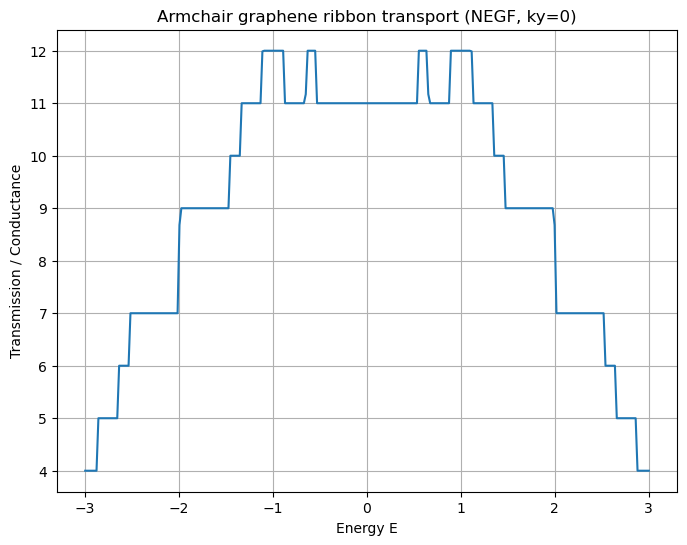

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# ================= 参数 =================
const = 0.0
e0    = 0.0
t     = 1.0
a     = 1.0
ky    = 0.0
shuzi = 8
eta   = 1e-6
zazhi_device = (0.0, 0.0)    # 只在器件区加无序

# ================= 位置辅助函数 =================
def shulie(shuzi, suoyin):
    mylist = list(range(-shuzi//2, shuzi//2 + 1))
    if mylist[suoyin] > 0 and mylist[suoyin] % 2 == 1:
        return -1, 1
    if mylist[suoyin] > 0 and mylist[suoyin] % 2 == 0:
        return 1, 0
    if mylist[suoyin] == 0:
        return 0, 0
    if mylist[suoyin] < 0 and mylist[suoyin] % 2 == 1:
        return 1, 1
    if mylist[suoyin] < 0 and mylist[suoyin] % 2 == 0:
        return -1, 0

# ================= 构造完整哈密顿量 =================
def H_full(const, e0, t, a, ky, shuzi, disorder):
    H = np.zeros((2*shuzi, 2*shuzi), dtype=complex)

    # 层内块
    for i in range(shuzi):
        diyishu, diershu = shulie(shuzi, i)
        phase = np.exp(3j * a * ky * diershu)
        block = np.array([
            [-diyishu*const/2 + e0,        t*phase],
            [t*np.conj(phase),  +diyishu*const/2 + e0]
        ])
        H[2*i:2*i+2, 2*i:2*i+2] = block

    # 层间耦合
    hop = np.array([[t, 0], [0, t]])
    for i in range(shuzi-1):
        H[2*i:2*i+2, 2*(i+1):2*(i+1)+2] = hop
        H[2*(i+1):2*(i+1)+2, 2*i:2*i+2] = hop

    # 只在器件区加无序
    if disorder is not None:
        H += np.diag(np.random.uniform(disorder[0], disorder[1], 2*shuzi))

    return H

# ================= 提取 ky 相关跃迁 T =================
def extract_T_from_H(t, a, ky, shuzi):
    T = np.zeros((2*shuzi, 2*shuzi), dtype=complex)
    for i in range(shuzi):
        _, diershu = shulie(shuzi, i)
        phase = np.exp(3j * a * ky * diershu)
        r = 2*i
        c = 2*i + 1
        T[r, c] = t * phase
        T[c, r] = t * np.conj(phase)
    return T

# ================= 表面格林函数 =================
def surface_gf(ALR0, T, max_iter=800):
    g = np.linalg.inv(ALR0)
    for _ in range(max_iter):
        g_new = np.linalg.inv(ALR0 - T.conj().T @ g @ T)
        g = 0.5 * g + 0.5 * g_new
    return g

# ================= 计算透射率 =================
def transmission(E, H_device, H_lead, Tmat):
    dim = H_device.shape[0]
    z = E + 1j*eta

    ALR_lead = z*np.eye(dim) - H_lead
    gL = surface_gf(ALR_lead, Tmat)
    gR = surface_gf(ALR_lead, Tmat)

    SigmaL = Tmat.conj().T @ gL @ Tmat
    SigmaR = Tmat @ gR @ Tmat.conj().T

    GammaL = 1j * (SigmaL - SigmaL.conj().T)
    GammaR = 1j * (SigmaR - SigmaR.conj().T)

    GR = np.linalg.inv(z*np.eye(dim) - H_device - SigmaL - SigmaR)

    return np.real(np.trace(GammaL @ GR @ GammaR @ GR.conj().T))

# ================= 主程序 =================
# lead（无无序）
H_lead = H_full(const, e0, t, a, ky, shuzi, disorder=None)

# device（有无序）
H_device = H_full(const, e0, t, a, ky, shuzi, disorder=zazhi_device)

# T 矩阵来源于 ky
Tmat = extract_T_from_H(t, a, ky, shuzi)

# 扫描能量
E_list = np.linspace(-3, 3, 300)
G_list = []

for E in E_list:
    G_list.append(transmission(E, H_device, H_lead, Tmat))

# ================= 作图 =================
plt.figure(figsize=(8,6))
plt.plot(E_list, G_list)
plt.xlabel("Energy E")
plt.ylabel("Transmission / Conductance")
plt.title("Armchair graphene ribbon transport (NEGF, ky=0)")
plt.grid(True)
plt.show()
